# HR Employee Attrition Analysis (Satisfaction Attrition Analysis)

**Tujuan notebook ini:** menjawab business question ke-5: Bagaimana pengaruh kepuasan kerja terhadap attrition?

## 1. Setup & Load Data

Load data langsung dari MySQL supaya konsisten dengan sumber data yang sudah dinormalisasi.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

load_dotenv()

host = os.environ.get("DB_HOST")
user = os.environ.get("DB_USER")
password = os.environ.get("DB_PASSWORD")
database = os.environ.get("DB_NAME")

url_connect = f"mysql+pymysql://{user}:{password}@{host}/{database}"

engine = create_engine(url_connect)

In [2]:
query = """ SELECT
                e.attrition,
                ss.job_satisfaction,
                ss.environment_satisfaction,
                ss.relationship_satisfaction,
                ss.job_involvement,
                ss.work_life_balance
            FROM employees e
            JOIN satisfaction_scores ss ON e.employee_id = ss.employee_id"""

with engine.connect() as koneksi:
    df = pd.read_sql(query, con=koneksi)

In [3]:
print(f"Jumlah baris & kolom: {df.shape}")
df.head()

Jumlah baris & kolom: (1470, 6)


,attrition,job_satisfaction,environment_satisfaction,relationship_satisfaction,job_involvement,work_life_balance
0,Yes,4,2,1,3,1
1,No,2,3,4,2,3
2,Yes,3,4,2,2,3
3,No,3,4,3,3,3
4,No,2,1,4,3,3


## 2. Analisis Deskriptif

Lakukan analisis deskriptif sederhana untuk mengetahui hubungan kepuasan kerja terhadap attrition.

In [4]:
satisfaction_attrition_rate = df.groupby('attrition').agg(['mean', 'median'])
satisfaction_attrition_rate

job_satisfaction        environment_satisfaction         \
                      mean median                     mean median   
attrition                                                           
No                2.778589    3.0                 2.771290    3.0   
Yes               2.468354    3.0                 2.464135    3.0   

          relationship_satisfaction        job_involvement         \
                               mean median            mean median   
attrition                                                           
No                         2.733982    3.0        2.770479    3.0   
Yes                        2.599156    3.0        2.518987    3.0   

          work_life_balance         
                       mean median  
attrition                           
No                 2.781022    3.0  
Yes                2.658228    3.0

Dari rata-rata dan median tiap kolom kepuasan, terlihat pola yang konsisten, yaitu karyawan yang keluar (`attrition = Yes`) cenderung memiliki skor kepuasan yang sedikit lebih rendah di semua aspek dibanding yang bertahan, meski mediannya sama-sama di angka 3 untuk semua kolom (median kurang sensitif menangkap perbedaan kecil ini). Untuk melihat pola yang lebih jelas, hitung attrition rate di tiap level kepuasan (1-4) secara langsung.

In [5]:
df['attrition_map'] = df['attrition'].map({'Yes' : 1, 'No' : 0})

def attrition_rate(column):
    pct_attrition_rate = df.groupby(column).agg(
        percent_attrition = ('attrition_map', lambda x: round(x.mean()*100, 2))
    )
    return pct_attrition_rate.reset_index()
js_attrition_rate = attrition_rate('job_satisfaction')
es_attrition_rate = attrition_rate('environment_satisfaction')
rs_attrition_rate = attrition_rate('relationship_satisfaction')
ji_attrition_rate = attrition_rate('job_involvement')
wlb_attrition_rate = attrition_rate('work_life_balance')
all_attrition = pd.concat([js_attrition_rate, es_attrition_rate, 
                           rs_attrition_rate, ji_attrition_rate,
                           wlb_attrition_rate], axis=1)
all_attrition

,job_satisfaction,percent_attrition,environment_satisfaction,percent_attrition,relationship_satisfaction,percent_attrition,job_involvement,percent_attrition,work_life_balance,percent_attrition
0,1,22.84,1,25.35,1,20.65,1,33.73,1,31.25
1,2,16.43,2,14.98,2,14.85,2,18.93,2,16.86
2,3,16.52,3,13.69,3,15.47,3,14.40,3,14.22
3,4,11.33,4,13.45,4,14.81,4,9.03,4,17.65


Pola paling menonjol ada pada `job_involvement`, attrition rate-nya turun tajam dari **33,73%** di level 1 menjadi **9,03%** di level 4 — penurunan lebih dari 3,7 kali lipat, paling curam dibanding kolom lain. Pola serupa (menurun cukup konsisten seiring naiknya level kepuasan) juga terlihat pada `job_satisfaction`, `environment_satisfaction`, dan `relationship_satisfaction`. Namun `work_life_balance` menunjukkan pola yang tidak sepenuhnya linear — sempat naik lagi dari level 3 (14,22%) ke level 4 (17,65%), mengindikasikan hubungan yang tidak sesederhana "makin tinggi work-life balance, makin rendah attrition".

### Heatmap Korelasi

Sebelum menguji signifikansi masing-masing variabel, perlu dicek dulu apakah kelima aspek kepuasan ini saling berkorelasi tinggi satu sama lain.

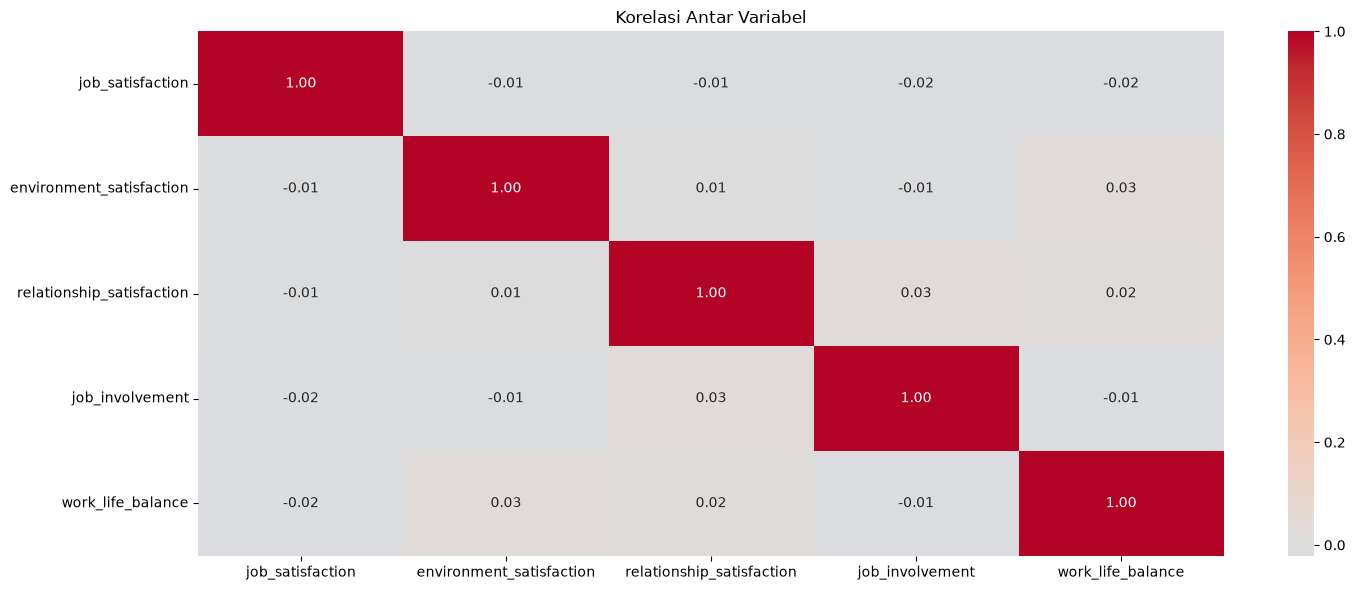

In [6]:
plt.figure(figsize=(15, 6))
corr = df.drop(['attrition', 'attrition_map'], axis=1).corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', center = 0, fmt ='.2f')
plt.title('Korelasi Antar Variabel')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Kelima variabel menunjukkan korelasi yang cukup rendah satu sama lain — seluruh pasangan berada di rentang -0,02 hingga 0,03, jauh dari indikasi multikolinearitas. Ini berarti kelima aspek kepuasan benar-benar mengukur dimensi yang berbeda-beda, bukan sekedar mencerminkan "rasa puas secara umum" yang sama.

### Pengelompokan Data Berdasarkan Attrition

Selanjutnya, bagi data untuk dikelompokkan berdasarkan attrition, sebagai persiapan untuk uji statistik di tahap berikutnya.

In [7]:
attrition_yes = df.loc[
    df['attrition'] == 'Yes', 
    ['job_satisfaction', 'environment_satisfaction', 
     'relationship_satisfaction', 'job_involvement', 'work_life_balance']
]

attrition_no = df.loc[
    df['attrition'] == 'No',
    ['job_satisfaction', 'environment_satisfaction', 
     'relationship_satisfaction', 'job_involvement', 'work_life_balance']
]

## 3. Uji Statistik & Effect Size

Menguji tingkat asosiasi antara 2 kelompok kategorikal (attrition Yes/No) terhadap masing-masing variabel kepuasan kerja (`job_satisfaction`, `environment_satisfaction`, `relationship_satisfaction`, `job_involvement`, `work_life_balance`), menggunakan **Mann-Whitney U test** dan **rank-biserial correlation** sebagai effect size.

In [8]:
def mann_whitney(df1, df2):
    mwu, p_value = stats.mannwhitneyu(df1, df2)
    hasil_mwu = f"Nilai statistik Mann-Whitney U test: {mwu}"
    if p_value < 0.0001:
        hasil_p_value = "P-value < 0.0001"
    else:
        hasil_p_value = f"P-value: {p_value:.4f}"
    return mwu, hasil_mwu, hasil_p_value

In [9]:
def rank_biserial(mwu, df1, df2):
    N1 = len(df1)
    N2 = len(df2)
    r_bs = 1 - (2 * mwu) / (N1 * N2)
    print(f"Nilai Rank-Biserial nya: {r_bs:.4f}")

### Terhadap `job_satisfaction`

In [10]:
mwu1, hasil_mwu1, p_value1 = mann_whitney(attrition_yes['job_satisfaction'], attrition_no['job_satisfaction'])
print(hasil_mwu1)
print(p_value1)

Nilai statistik Mann-Whitney U test: 123362.5
P-value < 0.0001


Nilai p-value kurang dari 0,0001 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `job_satisfaction`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [11]:
rank_biserial(mwu1, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.1557


Diperoleh nilai rank-biserial correlation-nya sebesar **0,1557** — belum mencapai ambang moderate (0,30) — menunjukkan kekuatan asosiasi **antara lemah hingga sedang**.

### Terhadap `environment_satisfaction`

In [12]:
mwu2, hasil_mwu2, p_value2 = mann_whitney(attrition_yes['environment_satisfaction'], attrition_no['environment_satisfaction'])
print(hasil_mwu2)
print(p_value2)

Nilai statistik Mann-Whitney U test: 124787.0
P-value: 0.0002


Nilai p-value sebesar 0,0002 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `environment_satisfaction`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [13]:
rank_biserial(mwu2, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.1459


Diperoleh nilai rank-biserial correlation-nya sebesar **0,1459** — belum mencapai ambang moderate (0,30) — menunjukkan kekuatan asosiasi **antara lemah hingga sedang**.

### Terhadap `relationship_satisfaction`

In [14]:
mwu3, hasil_mwu3, p_value3 = mann_whitney(attrition_yes['relationship_satisfaction'], attrition_no['relationship_satisfaction'])
print(hasil_mwu3)
print(p_value3)

Nilai statistik Mann-Whitney U test: 136678.5
P-value: 0.1020


Nilai p-value sebesar 0,1020 — lebih dari 0,05 — menunjukkan **tidak terdapat asosiasi yang signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `relationship_satisfaction`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [15]:
rank_biserial(mwu3, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.0646


Diperoleh nilai rank-biserial correlation-nya sebesar **0,0646** — jauh di bawah kategori lemah (0,10) — menunjukkan kekuatan asosiasi yang **sangat lemah**.

### Terhadap `job_involvement`

In [16]:
mwu5, hasil_mwu5, p_value5 = mann_whitney(attrition_yes['job_involvement'], attrition_no['job_involvement'])
print(hasil_mwu5)
print(p_value5)

Nilai statistik Mann-Whitney U test: 121957.0
P-value < 0.0001


Nilai p-value kurang dari 0,0001 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `job_involvement`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [17]:
rank_biserial(mwu5, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.1653


Diperoleh nilai rank-biserial correlation-nya sebesar **0,1653** — belum mencapai ambang moderate (0,30) — menunjukkan kekuatan asosiasi **antara lemah hingga sedang**.

### Terhadap `work_life_balance`

In [18]:
mwu4, hasil_mwu4, p_value4 = mann_whitney(attrition_yes['work_life_balance'], attrition_no['work_life_balance'])
print(hasil_mwu4)
print(p_value4)

Nilai statistik Mann-Whitney U test: 135709.5
P-value: 0.0465


Nilai p-value sebesar 0,0465 — sedikit di bawah ambang 0,05 — menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `work_life_balance`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [19]:
rank_biserial(mwu4, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.0712


Diperoleh nilai rank-biserial correlation-nya sebesar **0,0712** — jauh di bawah kategori lemah (0,10) — menunjukkan kekuatan asosiasi yang **sangat lemah**.

## 4. Visualisasi

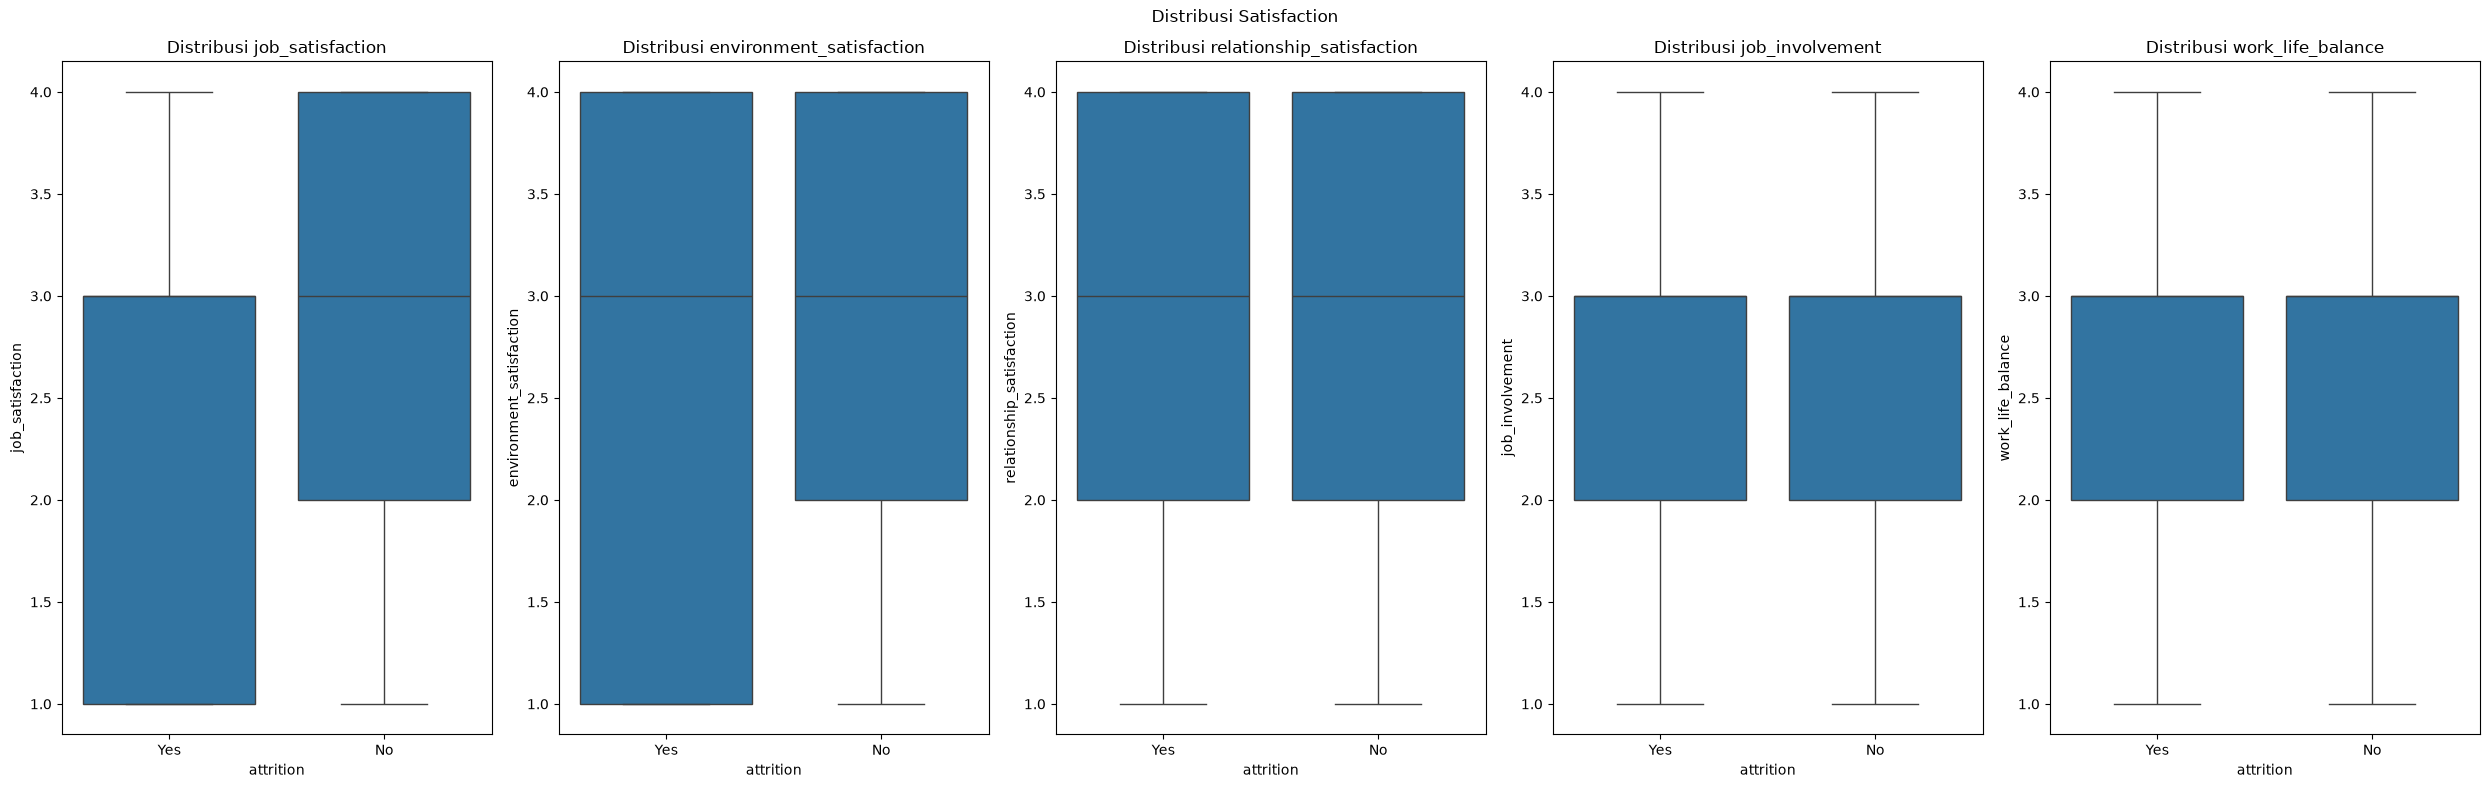

In [20]:
n = len(df.drop(['attrition', 'attrition_map'], axis=1).columns)
fig, axes = plt.subplots(1, n, figsize=(5*n, 8))

for ax, column in zip(axes, df.drop(['attrition', 'attrition_map'], axis=1).columns):
    sns.boxplot(data=df, x='attrition', y=column, ax=ax)
    ax.set_title(f"Distribusi {column}")

plt.suptitle("Distribusi Satisfaction")
plt.tight_layout()
plt.show()

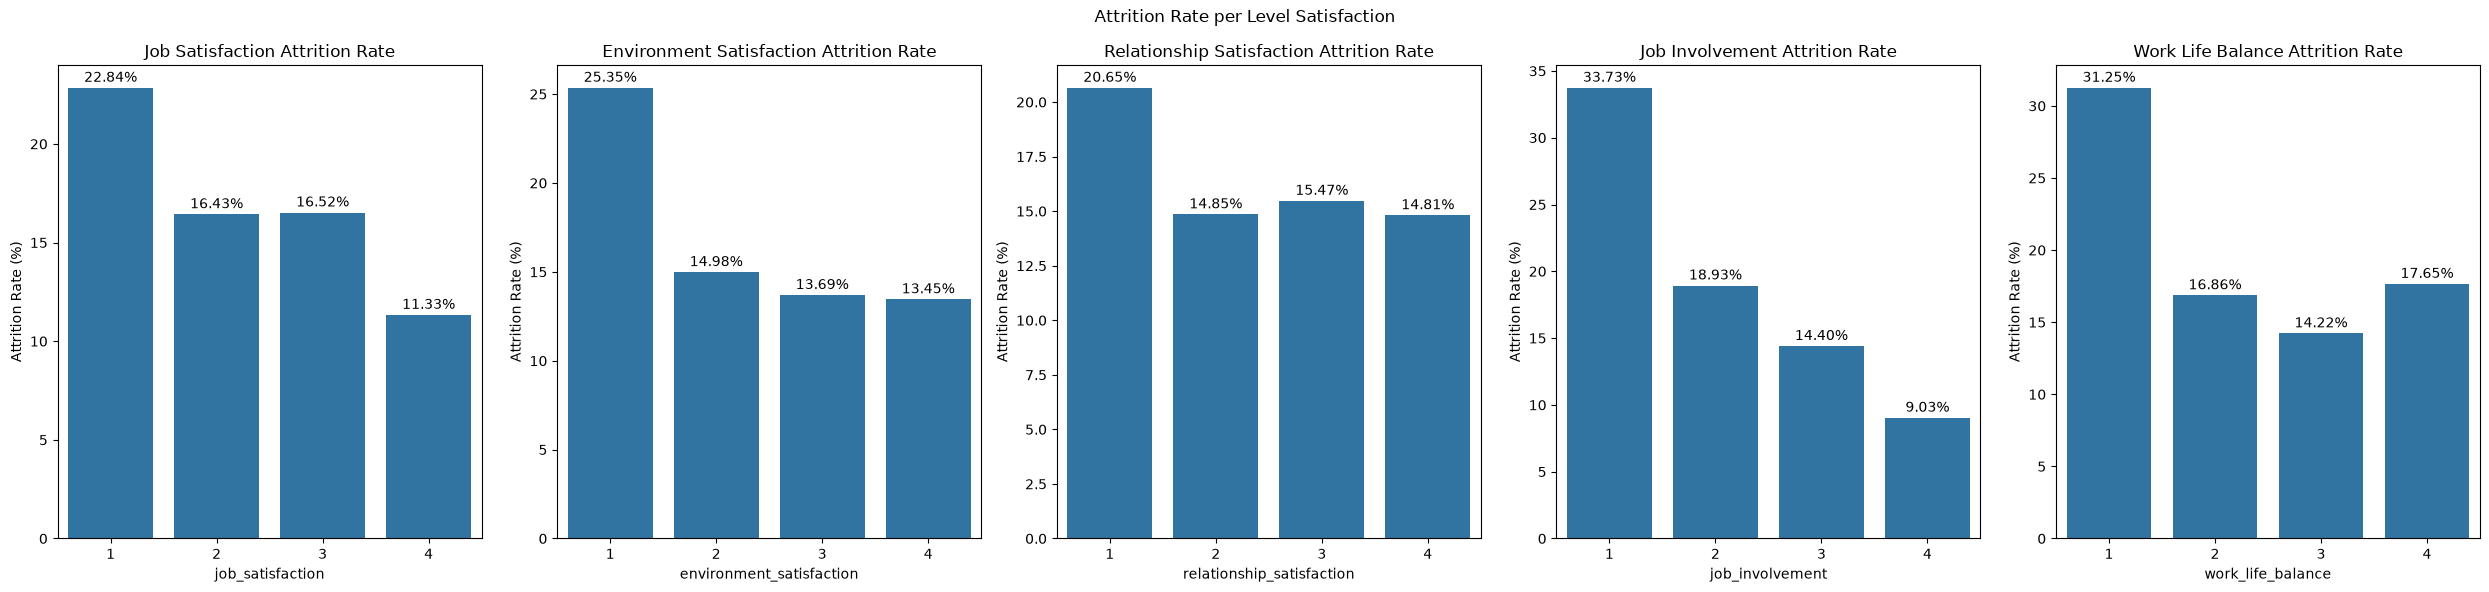

In [21]:
column_order = ['Job Satisfaction', 'Environment Satisfaction', 'Relationship Satisfaction', 'Job Involvement', 'Work Life Balance']
n = len(df.drop(['attrition', 'attrition_map'], axis=1).columns)
fig, axes = plt.subplots(1, n, figsize=(5*n, 6))

sns.barplot(js_attrition_rate, x='job_satisfaction', y='percent_attrition', ax=axes[0])
sns.barplot(es_attrition_rate, x='environment_satisfaction', y='percent_attrition', ax=axes[1])
sns.barplot(rs_attrition_rate, x='relationship_satisfaction', y='percent_attrition', ax=axes[2])
sns.barplot(ji_attrition_rate, x='job_involvement', y='percent_attrition', ax=axes[3])
sns.barplot(wlb_attrition_rate, x='work_life_balance', y='percent_attrition', ax=axes[4])

for ax, column in zip(axes, column_order):
    ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=2)
    ax.set_title(f"{column} Attrition Rate")
    ax.set_ylabel("Attrition Rate (%)")

plt.suptitle("Attrition Rate per Level Satisfaction")
plt.tight_layout()
plt.show()

## Kesimpulan

Dari kelima aspek kepuasan kerja yang diuji dengan Mann-Whitney U test, tiga di antaranya menunjukkan asosiasi yang meyakinkan secara statistik, dan dua lainnya menunjukkan asosiasi yang lemah atau tidak signifikan.

**Job Involvement** menunjukkan efek paling kuat di antara kelima variabel (U = 121.957,0; p < 0,0001; rank-biserial = 0,1653), dengan attrition rate menurun tajam dari 33,73% (level 1) menjadi 9,03% (level 4) — pola paling konsisten dan paling curam dibanding variabel lain.

**Job Satisfaction** (U = 123.362,5; p < 0,0001; rank-biserial = 0,1557) dan **Environment Satisfaction** (U = 124.787,0; p = 0,0002; rank-biserial = 0,1459) juga signifikan, dengan pola serupa: attrition rate menurun seiring naiknya level kepuasan (job satisfaction dari 22,84% ke 11,33%; environment satisfaction dari 25,35% ke 13,45%).

**Work Life Balance** signifikan secara statistik namun tipis (U = 135.709,5; p = 0,0465; rank-biserial = 0,0712) — mirip kasus `years_since_last_promotion` di Q4, kombinasi p-value tipis dan effect size kecil ini menandakan hasil yang secara praktis kurang meyakinkan. Pola datanya pun tidak sepenuhnya linear (naik lagi di level 4 setelah turun di level 3), berbeda dari 3 variabel signifikan lainnya yang polanya konsisten menurun.

**Relationship Satisfaction** tidak signifikan (U = 136.678,5; p = 0,1020; rank-biserial = 0,0646) — dari kelima aspek kepuasan yang diuji, kepuasan terhadap relasi kerja dengan rekan/atasan ternyata tidak terbukti menjadi faktor pembeda antara karyawan yang keluar dan yang bertahan.

**Catatan korelasi antar variabel**: berbeda dari variabel tenure di Q4 yang saling berkorelasi cukup tinggi (0,51-0,77), kelima variabel kepuasan ini praktis **tidak saling berkorelasi** — seluruh pasangan berada di rentang -0,02 hingga 0,03, jauh dari indikasi multikolinearitas. Ini berarti kelima aspek kepuasan (job satisfaction, environment satisfaction, relationship satisfaction, job involvement, work-life balance) benar-benar mengukur dimensi yang berbeda-beda, bukan sekadar mencerminkan "rasa puas secara umum" yang sama. Konsekuensinya, hasil uji Mann-Whitney pada tiap variabel bisa diinterpretasikan sebagai efek yang relatif independen satu sama lain — misalnya, tingginya asosiasi `job_involvement` dengan attrition tidak serta-merta berarti karyawan tersebut juga puas/tidak puas dengan lingkungan kerjanya.

**Catatan batasan**: seperti pada business question sebelumnya, hasil ini menunjukkan asosiasi, bukan hubungan sebab-akibat, karena sifat data yang cross-sectional.

**Implikasi praktis**: dari kelima aspek kepuasan kerja, **job involvement** adalah yang paling layak menjadi prioritas utama HR — keterlibatan karyawan terhadap pekerjaannya tampak menjadi pembeda paling tajam antara yang bertahan dan yang keluar. Job satisfaction dan environment satisfaction juga layak diperhatikan, sementara relationship satisfaction dan work-life balance tidak terbukti menjadi faktor penentu yang kuat pada dataset ini.